In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing

housing = fetch_california_housing(as_frame=True)
df = housing.frame
print(df.head())
print(df.columns.tolist())


   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  
['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude', 'MedHouseVal']


### Chart 1 — Scatter plot
Income vs house value

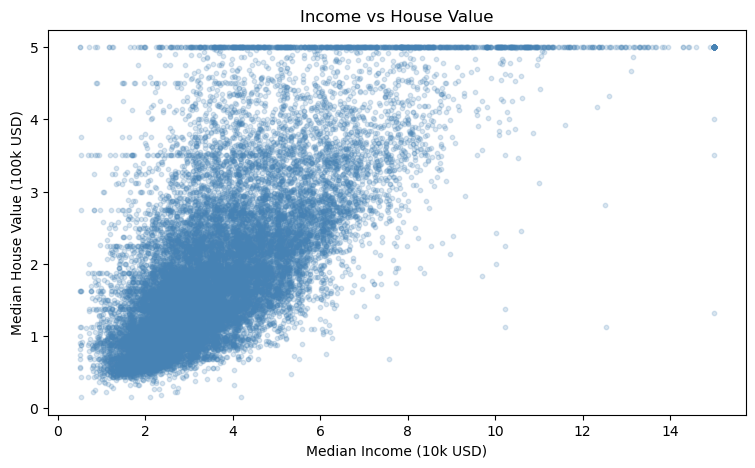

In [2]:

plt.figure(figsize=(9, 5))
plt.scatter(df['MedInc'], df['MedHouseVal'], alpha=0.2, s=10, color='steelblue')
plt.xlabel('Median Income (10k USD)')
plt.ylabel('Median House Value (100k USD)')
plt.title('Income vs House Value')
plt.show()

### Chart 2 — Correlation heatmap
All pairwise correlations

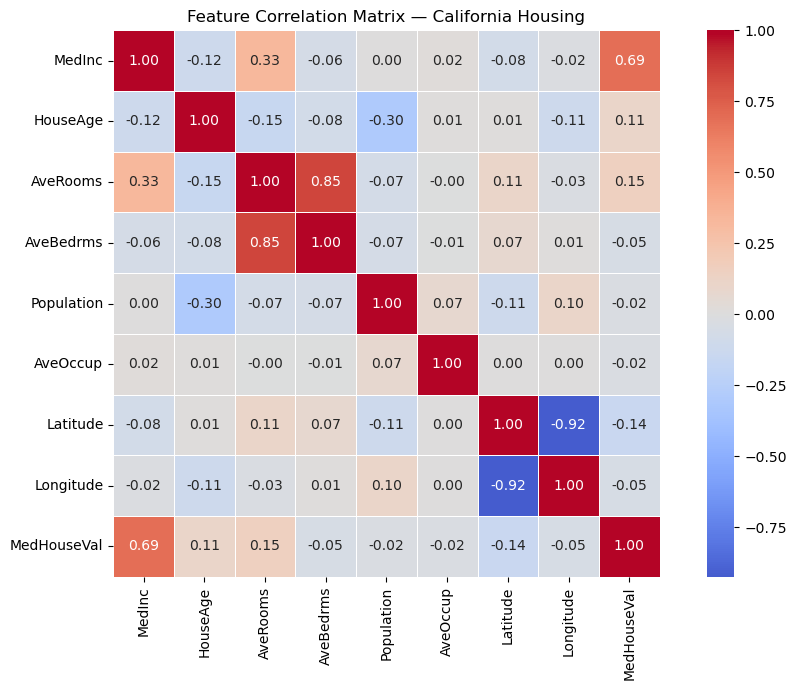

In [3]:

corr = df.corr()
plt.figure(figsize=(10, 7))
sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    linewidths=0.5,
    square=True
)
plt.title('Feature Correlation Matrix — California Housing')
plt.tight_layout()
plt.show()

### Chart 3 — Pair plot
All combinations at once (sampled)

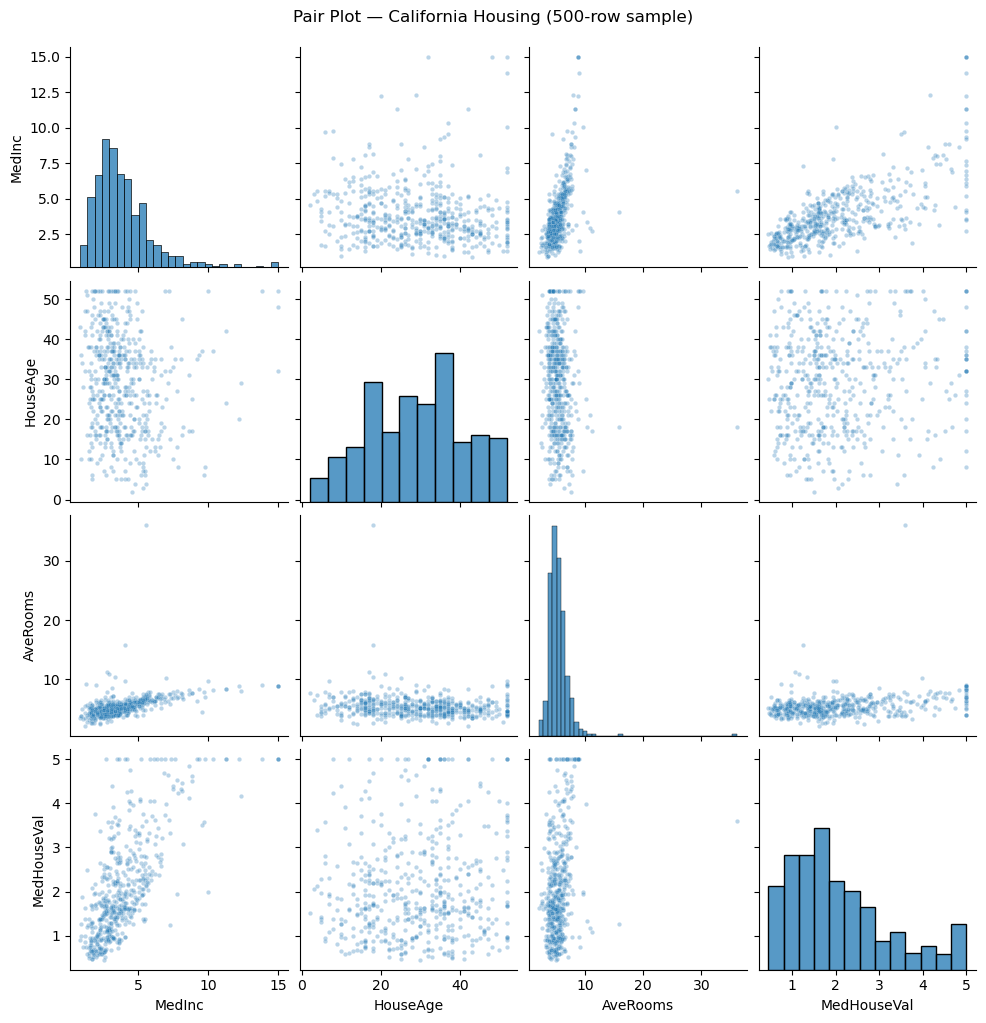

In [4]:
subset = df[['MedInc', 'HouseAge', 'AveRooms', 'MedHouseVal']].sample(500, random_state=42)
sns.pairplot(subset, plot_kws={'alpha': 0.3, 's': 10})
plt.suptitle('Pair Plot — California Housing (500-row sample)', y=1.02)
plt.show()


### Chart 4 — Grouped bar chart
Average charges by smoker + sex

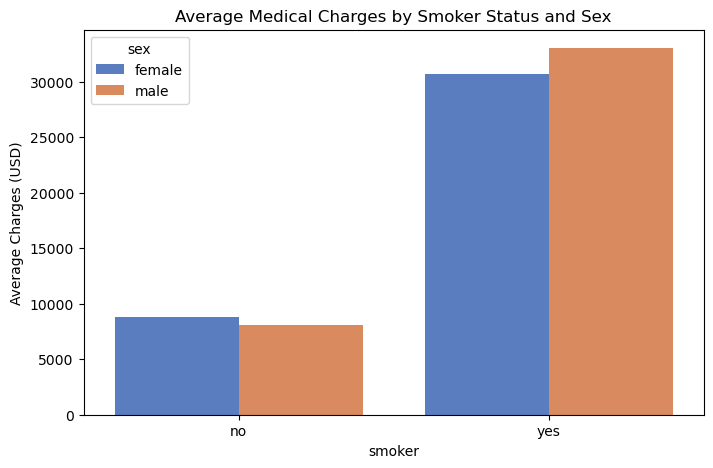

In [6]:
url = "https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv"
ins = pd.read_csv(url)
grouped = ins.groupby(['smoker', 'sex'])['charges'].mean().reset_index()
plt.figure(figsize=(8, 5))
sns.barplot(data=grouped, x='smoker', y='charges', hue='sex', palette='muted')
plt.title('Average Medical Charges by Smoker Status and Sex')
plt.ylabel('Average Charges (USD)')
plt.show()
